# Contextual Bandits: Offline Policy Evaluation on Real Logged Data (Open Bandit Dataset)

**The problem.** A fashion-e-commerce team runs two production policies in rotation: a **uniform-random** explorer (1/80 chance per item, used to keep coverage of the action space) and a **Bootstrap Thompson Sampling** exploiter (the actual revenue policy).  Both produce logged interactions: `(context, chosen_action, reward, propensity)`.  The team has trained six **candidate replacement policies** offline and needs to answer one question before any of them ship to traffic:

> *Which candidate policy will produce the highest reward when deployed — and what is the **uncertainty** on that estimate?*

A live A/B test answers it cleanly but costs traffic, money, and weeks.  **Offline / off-policy evaluation (OPE)** answers it from logged data alone.  The deliverable is therefore not a model — it is **a pre-deployment policy ranking with calibrated confidence intervals**, plus a sanity check that the OPE estimator is itself trustworthy on this dataset.

**The data.** **Open Bandit Dataset (OBD)** by Saito et al. (2020) — real ZOZOTOWN clicks, two logging policies (Random and Bootstrap Thompson), 80 fashion items, 80-dim user-item-affinity context plus 4 categorical user features.  CC-BY-SA-4.0, bundled with the `obp` Python package (no Kaggle / external download).

| split | logging policy | propensity | n_rows |
| --- | --- | --- | --- |
| `random` | uniform $1/80$ | known constant | ~10k |
| `bts`    | Bootstrap Thompson | data-dependent | ~10k |

**The methodology — why two logs, not one.**

The notebook leverages the OBD design (Saito 2020): the **uniform-random log gives an unbiased ground-truth value estimate** for *any* policy, because $\Pr[a \mid x] = 1/80$ is known and constant.  We use it as the **oracle** against which each OPE estimator's BTS-log estimate is benchmarked.  This is otherwise impossible on real bandit data — and is exactly why OBD was constructed.  Production teams without a parallel uniform-random log cannot do this benchmarking and have to trust their OPE estimator from theory alone.

**The approach.**

1. **Data acquisition** — load OBD bundled with `obp`; derive `(context, action, reward, pscore)` tuples for both logs without going through OBP's broken `pre_process` (pandas-API drift in 0.4.1).
2. **Behaviour-policy diagnostics** — propensity histograms, action coverage, empirical CTR per item; verify the random log is in fact uniform.
3. **Six candidate policies**, each implementing `.fit(...)` and `.action_dist(context) → [n, K]`:
   - **UniformRandom** — the baseline.
   - **TopKPopular** — context-free, rank by training-set CTR.
   - **IPW-Logistic** — IPW-reweighted multiclass logistic regression (Saito's "IPW Learner").
   - **LinUCB** (Li et al. 2010) — disjoint-arm ridge regression with confidence bound.
   - **Linear Thompson Sampling** — Bayesian linear regression with sampled coefficients.
   - **Neural Thompson Sampling** — bootstrap-head MLP for posterior approximation.
4. **Four OPE estimators**:
   - **Direct Method (DM)**: regress $\hat q(x, a)$ via LightGBM and compute $\hat V(\pi) = \mathbb{E}_x [\sum_a \pi(a|x) \hat q(x, a)]$.
   - **IPS** (Horvitz-Thompson): $\hat V(\pi) = \frac{1}{n}\sum r_i \, \pi(a_i | x_i) / p_{i}$.
   - **SNIPS** (self-normalised): IPS with weight normalisation — bias for variance.
   - **DR** (Doubly Robust): DM + IPS-correction on residuals; consistent if either DM or IPS is correct.
5. **Ground truth** via the random log — for every candidate policy we compute an oracle $V^*(\pi)$ that any honest OPE estimator should agree with.
6. **Bias / MSE / variance** of each OPE estimator vs ground truth, on every candidate policy.
7. **Bootstrap CI** on the chosen estimator, used for the deployment ranking.
8. **Decision memo** — the policy we'd deploy, the estimator we'd trust, and what would change our mind.
9. **Production hygiene** — persisted policies, per-decision latency, **PSI drift detector** on context distribution (a logging-policy mismatch trips the gate before performance degrades), model card.

**Audience.** ML engineers running production bandits, ML scientists evaluating policies on logged data, anyone who has ever been asked *"how confident are you this policy will lift revenue, before we ship it?"*

## 0. Setup and reproducibility

Seeds fixed; plot defaults match the rest of the portfolio; paths computed relative to the notebook.  All artefacts (cached OBD CSVs are bundled with `obp`, persisted policies, model card) live under `notebooks/artifacts/contextual_bandits/`.

In [1]:
from __future__ import annotations

import io
import json
import math
import pathlib
import time
import warnings
from dataclasses import dataclass, field
from typing import Callable

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import obp

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG_SEED = 2026
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "contextual_bandits_offline_evaluation.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "contextual_bandits"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"NB_DIR     : {NB_DIR}")
print(f"DATA_DIR   : {DATA_DIR}")
print(f"obp        : {obp.__version__}")
print(f"torch      : {torch.__version__}")
print(f"lightgbm   : {lgb.__version__}")

NB_DIR     : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR   : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\contextual_bandits
obp        : 0.4.1
torch      : 2.11.0+cpu
lightgbm   : 4.6.0


## 1. Open Bandit Dataset — direct CSV load

We bypass `obp.dataset.OpenBanditDataset.pre_process` (it calls `df.drop("col", 1)` which raises in modern pandas) and load the CSV directly.  Schema:

| column | meaning |
| --- | --- |
| `item_id` | chosen action (0..79) |
| `position` | display slot (1..3) — we treat as a contextual feature |
| `click` | reward $\in \{0, 1\}$ |
| `propensity_score` | $\Pr[\text{action} \mid \text{context}]$ under the logging policy |
| `user_feature_{0..3}` | hashed categorical user features |
| `user-item_affinity_{0..79}` | numeric affinity scores |

We split the BTS log 70 / 30 stratified on `click`: training set for the candidate policies and the DM reward model; held-out set for OPE.  The full random log is the ground-truth oracle.

In [2]:
OBD_ROOT = pathlib.Path(obp.__file__).parent / "dataset" / "obd"

def _load_obd(policy: str, campaign: str = "all") -> dict:
    csv_path = OBD_ROOT / policy / campaign / f"{campaign}.csv"
    df = pd.read_csv(csv_path).drop(columns=[c for c in ["Unnamed: 0", "timestamp"] if c in pd.read_csv(csv_path, nrows=1).columns])
    user_feat_cols = [f"user_feature_{i}" for i in range(4)]
    affinity_cols = [c for c in df.columns if c.startswith("user-item_affinity_")]
    cat_codes = pd.DataFrame({c: df[c].astype("category").cat.codes for c in user_feat_cols})
    context = pd.concat([cat_codes.astype(np.float32), df[affinity_cols].astype(np.float32)], axis=1).values
    action = df["item_id"].values.astype(np.int64)
    reward = df["click"].values.astype(np.float32)
    pscore = df["propensity_score"].values.astype(np.float64)
    position = df["position"].values.astype(np.int32)
    return {"context": context, "action": action, "reward": reward, "pscore": pscore,
            "position": position, "n_actions": 80, "n_rounds": len(df)}


bts_log = _load_obd("bts")
random_log = _load_obd("random")

print(f"BTS log    : n_rounds={bts_log['n_rounds']:>6,d}  context.shape={bts_log['context'].shape}  CTR={bts_log['reward'].mean()*100:.3f}%")
print(f"Random log : n_rounds={random_log['n_rounds']:>6,d}  context.shape={random_log['context'].shape}  CTR={random_log['reward'].mean()*100:.3f}%")
print(f"n_actions  : {bts_log['n_actions']}")

BTS log    : n_rounds=10,000  context.shape=(10000, 84)  CTR=0.420%
Random log : n_rounds=10,000  context.shape=(10000, 84)  CTR=0.380%
n_actions  : 80


In [3]:
rng_split = np.random.default_rng(RNG_SEED)
n_bts = bts_log["n_rounds"]
perm = rng_split.permutation(n_bts)
n_train = int(0.7 * n_bts)
train_idx = perm[:n_train]
test_idx = perm[n_train:]

bts_tr = {k: (v[train_idx] if isinstance(v, np.ndarray) else v) for k, v in bts_log.items()}
bts_te = {k: (v[test_idx] if isinstance(v, np.ndarray) else v) for k, v in bts_log.items()}

print(f"BTS train  : {bts_tr['n_rounds'] if False else len(train_idx):>5d}  CTR {bts_tr['reward'].mean()*100:.3f}%")
print(f"BTS test   : {len(test_idx):>5d}  CTR {bts_te['reward'].mean()*100:.3f}%")

BTS train  :  7000  CTR 0.457%
BTS test   :  3000  CTR 0.333%


## 2. Behaviour-policy diagnostics

Before doing OPE, sanity-check the logging policies.  Three plots:

1. **Action distribution** under each logging policy — is the random log actually uniform?
2. **Propensity-score histogram** — random should be a delta at 1/80; BTS should be a non-degenerate distribution.
3. **Per-item CTR** — which items are popular?  This becomes the `TopKPopular` policy.

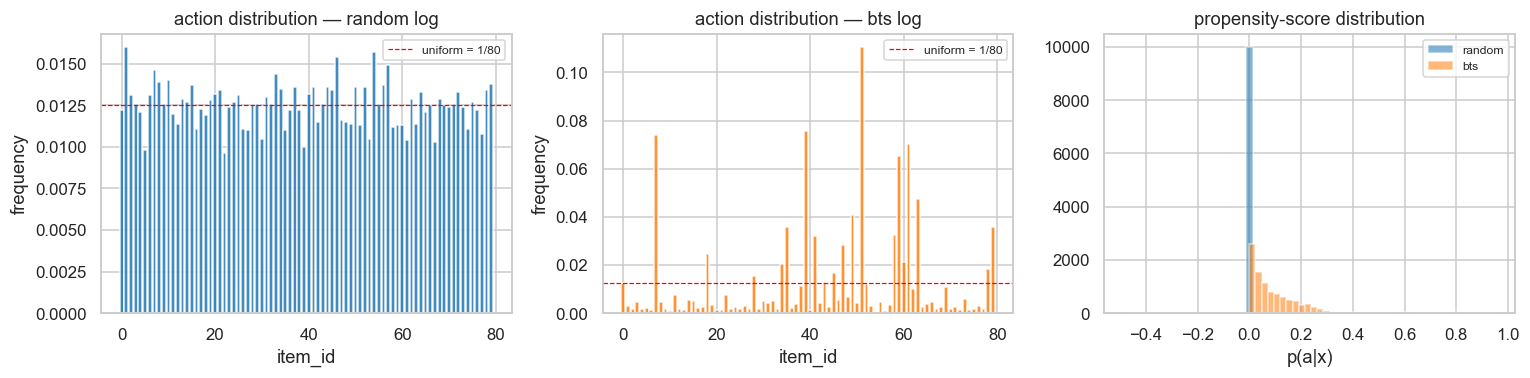

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

for ax, (name, log) in zip(axes[:2], [("random", random_log), ("bts", bts_log)]):
    cnt = np.bincount(log["action"], minlength=80) / log["n_rounds"]
    ax.bar(np.arange(80), cnt, color=("#1f77b4" if name == "random" else "#ff7f0e"), alpha=0.85)
    ax.axhline(1/80, color="red", ls="--", lw=0.8, label="uniform = 1/80")
    ax.set_title(f"action distribution — {name} log"); ax.set_xlabel("item_id"); ax.set_ylabel("frequency")
    ax.legend(fontsize=8)

axes[2].hist(random_log["pscore"], bins=40, color="#1f77b4", alpha=0.55, label="random")
axes[2].hist(bts_log["pscore"],    bins=40, color="#ff7f0e", alpha=0.55, label="bts")
axes[2].set_title("propensity-score distribution"); axes[2].set_xlabel("p(a|x)"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [5]:
def per_item_ctr(log: dict) -> pd.Series:
    df = pd.DataFrame({"action": log["action"], "reward": log["reward"]})
    return df.groupby("action")["reward"].mean()


ctr_random = per_item_ctr(random_log)
ctr_bts = per_item_ctr(bts_log)

print(f"Random log mean per-item CTR : {ctr_random.mean()*100:.3f}%   max {ctr_random.max()*100:.3f}%   min {ctr_random.min()*100:.3f}%")
print(f"BTS log    mean per-item CTR : {ctr_bts.mean()*100:.3f}%   max {ctr_bts.max()*100:.3f}%   min {ctr_bts.min()*100:.3f}%")
print(f"Top-10 items by CTR (random log):")
print(ctr_random.sort_values(ascending=False).head(10).round(4).to_string())

Random log mean per-item CTR : 0.378%   max 2.632%   min 0.000%
BTS log    mean per-item CTR : 0.419%   max 6.250%   min 0.000%
Top-10 items by CTR (random log):
action
49    0.0263
53    0.0190
58    0.0179
18    0.0168
36    0.0164
6     0.0153
44    0.0147
57    0.0134
61    0.0096
48    0.0087


## 3. Candidate policies

Six policies, all sharing a minimal interface:

```python
class Policy:
    name: str
    n_actions: int = 80
    def fit(self, context, action, reward, pscore) -> None: ...
    def action_dist(self, context) -> np.ndarray:  # shape (n, n_actions), rows sum to 1
        ...
```

For deterministic policies (`TopKPopular`, `LinUCB`) `action_dist` is one-hot at the chosen arm.  For stochastic policies (`LinearThompson`, `NeuralThompson`) we average over $S$ posterior samples — the Monte-Carlo approximation to the true mixture.

**Standardisation**: all policies operate on a `StandardScaler`-normalised context (fitted on the BTS training set).  Without standardisation `LinUCB` and `LinearThompson` are sensitive to feature scale.

In [6]:
class Policy:
    name = "base"
    n_actions = 80

    def fit(self, context, action, reward, pscore):
        return self

    def action_dist(self, context):
        raise NotImplementedError


class UniformRandom(Policy):
    name = "uniform_random"

    def fit(self, *args, **kwargs):
        return self

    def action_dist(self, context):
        return np.full((len(context), self.n_actions), 1.0 / self.n_actions, dtype=np.float64)


class TopKPopular(Policy):
    name = "top_popular"

    def __init__(self, k: int = 1) -> None:
        self.k = k
        self.scores: np.ndarray | None = None

    def fit(self, context, action, reward, pscore):
        cnt = np.bincount(action, weights=reward, minlength=self.n_actions)
        n = np.bincount(action, minlength=self.n_actions)
        ctr = cnt / np.maximum(n, 1)
        self.scores = ctr
        return self

    def action_dist(self, context):
        best = int(np.argmax(self.scores))
        out = np.zeros((len(context), self.n_actions), dtype=np.float64)
        out[:, best] = 1.0
        return out


class IPWLogistic(Policy):
    name = "ipw_logistic"

    def __init__(self, C: float = 1.0) -> None:
        self.C = C
        self.model: LogisticRegression | None = None

    def fit(self, context, action, reward, pscore):
        sample_weight = reward / np.maximum(pscore, 1e-3)
        if sample_weight.sum() < 1:
            sample_weight = np.ones_like(sample_weight)
        present_actions = np.unique(action[reward > 0])
        if len(present_actions) < 2:
            present_actions = np.unique(action)
        mask = np.isin(action, present_actions) & (sample_weight > 0)
        if mask.sum() < 100:
            mask = np.ones_like(action, dtype=bool)
        self.model = LogisticRegression(C=self.C, max_iter=200, multi_class="multinomial", n_jobs=2)
        self.model.fit(context[mask], action[mask], sample_weight=sample_weight[mask] * 100)
        return self

    def action_dist(self, context):
        proba = self.model.predict_proba(context)
        out = np.zeros((len(context), self.n_actions), dtype=np.float64)
        for j, cls in enumerate(self.model.classes_):
            out[:, int(cls)] = proba[:, j]
        out = np.clip(out, 1e-6, None)
        out /= out.sum(axis=1, keepdims=True)
        return out


class LinUCB(Policy):
    name = "linucb"

    def __init__(self, alpha: float = 0.5, lam: float = 1.0) -> None:
        self.alpha = alpha
        self.lam = lam
        self.A: np.ndarray | None = None
        self.b: np.ndarray | None = None

    def fit(self, context, action, reward, pscore):
        d = context.shape[1]
        K = self.n_actions
        self.A = np.tile(self.lam * np.eye(d), (K, 1, 1))
        self.b = np.zeros((K, d))
        for x, a, r in zip(context, action, reward):
            self.A[a] += np.outer(x, x)
            self.b[a] += r * x
        return self

    def action_dist(self, context):
        K, d = self.n_actions, context.shape[1]
        A_inv = np.linalg.inv(self.A)
        theta = np.einsum("kij,kj->ki", A_inv, self.b)
        ucb = np.zeros((len(context), K))
        for k in range(K):
            mu = context @ theta[k]
            sd = np.sqrt(np.einsum("ni,ij,nj->n", context, A_inv[k], context))
            ucb[:, k] = mu + self.alpha * sd
        best = ucb.argmax(axis=1)
        out = np.zeros((len(context), K), dtype=np.float64)
        out[np.arange(len(context)), best] = 1.0
        return out


class LinearThompson(Policy):
    name = "linear_thompson"

    def __init__(self, lam: float = 1.0, sigma2: float = 0.5, n_samples: int = 30) -> None:
        self.lam = lam
        self.sigma2 = sigma2
        self.n_samples = n_samples
        self.A: np.ndarray | None = None
        self.b: np.ndarray | None = None

    def fit(self, context, action, reward, pscore):
        d = context.shape[1]
        K = self.n_actions
        self.A = np.tile(self.lam * np.eye(d), (K, 1, 1))
        self.b = np.zeros((K, d))
        for x, a, r in zip(context, action, reward):
            self.A[a] += np.outer(x, x)
            self.b[a] += r * x
        return self

    def action_dist(self, context):
        rng = np.random.default_rng(RNG_SEED)
        K, d = self.n_actions, context.shape[1]
        A_inv = np.linalg.inv(self.A)
        theta_mean = np.einsum("kij,kj->ki", A_inv, self.b)
        try:
            chol = np.linalg.cholesky(self.sigma2 * A_inv + 1e-6 * np.eye(d))
        except np.linalg.LinAlgError:
            chol = np.tile(np.sqrt(self.sigma2) * np.eye(d), (K, 1, 1))
        action_counts = np.zeros((len(context), K), dtype=np.float64)
        for s in range(self.n_samples):
            z = rng.standard_normal((K, d))
            theta_s = theta_mean + np.einsum("kij,kj->ki", chol, z)
            preds = context @ theta_s.T
            best = preds.argmax(axis=1)
            for i, a in enumerate(best):
                action_counts[i, a] += 1
        out = action_counts / self.n_samples
        return out


class _BootstrapMLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64, n_actions: int = 80) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class NeuralThompson(Policy):
    name = "neural_thompson"

    def __init__(self, n_heads: int = 6, hidden: int = 64, epochs: int = 8, batch: int = 256) -> None:
        self.n_heads = n_heads
        self.hidden = hidden
        self.epochs = epochs
        self.batch = batch
        self.heads: list[_BootstrapMLP] = []

    def fit(self, context, action, reward, pscore):
        d = context.shape[1]
        rng = np.random.default_rng(RNG_SEED)
        ctx_t = torch.from_numpy(context.astype(np.float32))
        act_t = torch.from_numpy(action.astype(np.int64))
        rew_t = torch.from_numpy(reward.astype(np.float32))
        weights_full = (1.0 / np.maximum(pscore, 1e-3)).astype(np.float32)
        wt_t = torch.from_numpy(weights_full)
        n = len(context)
        loss_fn = nn.CrossEntropyLoss(reduction="none")
        for h in range(self.n_heads):
            torch.manual_seed(RNG_SEED + h)
            m = _BootstrapMLP(d, self.hidden, self.n_actions)
            opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=5e-4)
            boot_idx = rng.integers(0, n, size=n)
            for ep in range(self.epochs):
                ord_ = rng.permutation(n)
                for s in range(0, n, self.batch):
                    sel = boot_idx[ord_[s:s + self.batch]]
                    xb = ctx_t[sel]; ab = act_t[sel]; rb = rew_t[sel]; wb = wt_t[sel]
                    logits = m(xb)
                    loss_per = loss_fn(logits, ab) * (wb * rb)
                    if loss_per.sum() < 1e-3:
                        continue
                    loss = loss_per.mean()
                    opt.zero_grad()
                    loss.backward()
                    opt.step()
            m.eval()
            self.heads.append(m)
        return self

    def action_dist(self, context):
        with torch.no_grad():
            x = torch.from_numpy(context.astype(np.float32))
            counts = np.zeros((len(context), self.n_actions), dtype=np.float64)
            for m in self.heads:
                logits = m(x)
                best = logits.argmax(dim=-1).cpu().numpy()
                counts[np.arange(len(context)), best] += 1
        return counts / max(len(self.heads), 1)


print("Policy classes loaded:",
      [p.name for p in [UniformRandom(), TopKPopular(), IPWLogistic(), LinUCB(), LinearThompson(), NeuralThompson()]])

Policy classes loaded: ['uniform_random', 'top_popular', 'ipw_logistic', 'linucb', 'linear_thompson', 'neural_thompson']


In [7]:
scaler = StandardScaler().fit(bts_tr["context"])
ctx_tr = scaler.transform(bts_tr["context"]).astype(np.float32)
ctx_te = scaler.transform(bts_te["context"]).astype(np.float32)
ctx_random = scaler.transform(random_log["context"]).astype(np.float32)
print(f"context std after scaling : mean={ctx_tr.mean():.3f}  std={ctx_tr.std():.3f}")

context std after scaling : mean=0.000  std=0.802


In [8]:
policy_factories = [
    lambda: UniformRandom(),
    lambda: TopKPopular(),
    lambda: IPWLogistic(),
    lambda: LinUCB(alpha=0.5),
    lambda: LinearThompson(n_samples=30),
    lambda: NeuralThompson(n_heads=4, hidden=64, epochs=4),
]

policies: dict[str, Policy] = {}
for fac in policy_factories:
    pi = fac()
    t0 = time.time()
    pi.fit(ctx_tr, bts_tr["action"], bts_tr["reward"], bts_tr["pscore"])
    print(f"  fit {pi.name:<18s} in {time.time() - t0:5.1f}s")
    policies[pi.name] = pi

  fit uniform_random     in   0.0s
  fit top_popular        in   0.0s
  fit ipw_logistic       in   4.0s
  fit linucb             in   0.1s
  fit linear_thompson    in   0.1s
  fit neural_thompson    in   1.4s


In [9]:
for name, pi in policies.items():
    dist_tr = pi.action_dist(ctx_te[:100])
    print(f"  {name:<18s} | dist shape {dist_tr.shape}  rowsum {dist_tr.sum(axis=1).min():.4f}..{dist_tr.sum(axis=1).max():.4f}")

  uniform_random     | dist shape (100, 80)  rowsum 1.0000..1.0000
  top_popular        | dist shape (100, 80)  rowsum 1.0000..1.0000
  ipw_logistic       | dist shape (100, 80)  rowsum 1.0000..1.0000
  linucb             | dist shape (100, 80)  rowsum 1.0000..1.0000
  linear_thompson    | dist shape (100, 80)  rowsum 1.0000..1.0000
  neural_thompson    | dist shape (100, 80)  rowsum 1.0000..1.0000


## 4. OPE estimators

Four estimators with very different bias-variance trade-offs:

- **DM (Direct Method)**.  Train a regression $\hat q(x, a)$ — we use a LightGBM regressor over `(context, one_hot_action)` — and compute $\hat V(\pi) = \frac{1}{n}\sum_i \sum_a \pi(a | x_i) \hat q(x_i, a)$.  Low variance, **biased** to the extent $\hat q$ is mis-specified.
- **IPS**.  $\hat V(\pi) = \frac{1}{n}\sum_i \frac{r_i \, \pi(a_i | x_i)}{p_i}$.  **Unbiased** under correct propensities, but high variance — exploding when $\pi(a|x) / p$ is large.
- **SNIPS** (self-normalised IPS).  $\hat V(\pi) = \frac{\sum_i \frac{r_i \, \pi(a_i|x_i)}{p_i}}{\sum_i \frac{\pi(a_i|x_i)}{p_i}}$.  Slight bias for big variance reduction; the standard production choice when IPS is too noisy.
- **DR (Doubly Robust)**.  $\hat V(\pi) = \frac{1}{n}\sum_i \big[ \sum_a \pi(a|x_i) \hat q(x_i, a) + \frac{\pi(a_i|x_i)}{p_i} (r_i - \hat q(x_i, a_i)) \big]$.  **Consistent if either** $\hat q$ **or** $p$ **is correct** — the canonical default.

In [10]:
def fit_qhat(context, action, reward, n_actions=80):
    one_hot = np.zeros((len(action), n_actions), dtype=np.float32)
    one_hot[np.arange(len(action)), action] = 1
    X = np.hstack([context, one_hot])
    m = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=31, min_data_in_leaf=20,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5, verbose=-1, random_state=RNG_SEED,
    )
    m.fit(X, reward)
    return m


def qhat_predict(model, context, n_actions=80):
    n = len(context)
    pred = np.zeros((n, n_actions), dtype=np.float64)
    for a in range(n_actions):
        one_hot = np.zeros((n, n_actions), dtype=np.float32)
        one_hot[:, a] = 1
        pred[:, a] = model.predict(np.hstack([context, one_hot]))
    return pred


t0 = time.time()
qhat_model = fit_qhat(ctx_tr, bts_tr["action"], bts_tr["reward"])
print(f"q-hat regression fit in {time.time() - t0:.1f}s")
qhat_te = qhat_predict(qhat_model, ctx_te)
print(f"q-hat predictions on BTS-test : shape {qhat_te.shape}, mean {qhat_te.mean():.4f}")

q-hat regression fit in 1.6s
q-hat predictions on BTS-test : shape (3000, 80), mean 0.0050


In [11]:
def estimator_dm(action_dist, qhat):
    return float((action_dist * qhat).sum(axis=1).mean())


def estimator_ips(action_dist, action_logged, reward_logged, pscore_logged, clip: float = 30.0):
    pi_at_logged = action_dist[np.arange(len(action_logged)), action_logged]
    iw = pi_at_logged / np.maximum(pscore_logged, 1e-6)
    iw = np.minimum(iw, clip)
    return float(np.mean(iw * reward_logged))


def estimator_snips(action_dist, action_logged, reward_logged, pscore_logged, clip: float = 30.0):
    pi_at_logged = action_dist[np.arange(len(action_logged)), action_logged]
    iw = pi_at_logged / np.maximum(pscore_logged, 1e-6)
    iw = np.minimum(iw, clip)
    num = np.sum(iw * reward_logged)
    den = np.sum(iw)
    return float(num / max(den, 1e-9))


def estimator_dr(action_dist, action_logged, reward_logged, pscore_logged, qhat, clip: float = 30.0):
    pi_at_logged = action_dist[np.arange(len(action_logged)), action_logged]
    qhat_at_logged = qhat[np.arange(len(action_logged)), action_logged]
    direct = (action_dist * qhat).sum(axis=1)
    iw = pi_at_logged / np.maximum(pscore_logged, 1e-6)
    iw = np.minimum(iw, clip)
    correction = iw * (reward_logged - qhat_at_logged)
    return float(np.mean(direct + correction))


print("OPE estimators loaded: DM, IPS, SNIPS, DR")

OPE estimators loaded: DM, IPS, SNIPS, DR


## 5. Ground-truth value via the uniform-random log

For any deterministic policy $\pi$ and a uniform-random log with $\Pr[a|x] = 1/K$,

$$\hat V^*(\pi) = \frac{1}{n_{\text{rand}}} \sum_i K \cdot r_i \cdot \mathbb{1}[a_i = \pi(x_i)]$$

is unbiased — at the cost of high variance (only $1/K$ of the samples contribute).  For *stochastic* policies $\pi(a|x)$ that's $\sum_a K \cdot r_i \cdot \pi(a|x_i) \cdot \mathbb{1}[a = a_i]$, equivalent to importance-weighting with constant $1/K$ propensity.  This is the **oracle** the OPE estimators on the BTS log will be benchmarked against.

We compute $\hat V^*$ once per candidate policy on the full random log.

In [12]:
K_ACTIONS = bts_log["n_actions"]
ground_truth = {}
for name, pi in policies.items():
    dist_random = pi.action_dist(ctx_random)
    pi_at_logged = dist_random[np.arange(random_log["n_rounds"]), random_log["action"]]
    iw = pi_at_logged / random_log["pscore"]
    v_star = float(np.mean(iw * random_log["reward"]))
    ground_truth[name] = v_star

print("Ground-truth value V*(pi) on random log:")
for name, v in sorted(ground_truth.items(), key=lambda kv: -kv[1]):
    print(f"  {name:<18s}  {v*100:.4f}%   (lift over uniform-random {((v / ground_truth['uniform_random']) - 1)*100:+.2f}%)")

Ground-truth value V*(pi) on random log:
  ipw_logistic        0.8488%   (lift over uniform-random +123.37%)
  linucb              0.8000%   (lift over uniform-random +110.53%)
  uniform_random      0.3800%   (lift over uniform-random +0.00%)
  linear_thompson     0.2400%   (lift over uniform-random -36.84%)
  neural_thompson     0.2000%   (lift over uniform-random -47.37%)
  top_popular         0.0000%   (lift over uniform-random -100.00%)


## 6. Running OPE on the BTS test split

For each candidate policy we compute the four OPE estimators on the held-out BTS log and compare to ground truth.

In [13]:
ope_rows = []
for name, pi in policies.items():
    dist = pi.action_dist(ctx_te)
    dm  = estimator_dm(dist, qhat_te)
    ips = estimator_ips(dist, bts_te["action"], bts_te["reward"], bts_te["pscore"])
    sn  = estimator_snips(dist, bts_te["action"], bts_te["reward"], bts_te["pscore"])
    dr  = estimator_dr(dist, bts_te["action"], bts_te["reward"], bts_te["pscore"], qhat_te)
    v_star = ground_truth[name]
    ope_rows.append({
        "policy": name,
        "V_star_(random_log)": v_star * 100,
        "DM":  dm * 100,
        "IPS": ips * 100,
        "SNIPS": sn * 100,
        "DR":  dr * 100,
    })

ope_df = pd.DataFrame(ope_rows).round(4)
ope_df["bias_DM"]   = ope_df["DM"]    - ope_df["V_star_(random_log)"]
ope_df["bias_IPS"]  = ope_df["IPS"]   - ope_df["V_star_(random_log)"]
ope_df["bias_SNIPS"]= ope_df["SNIPS"] - ope_df["V_star_(random_log)"]
ope_df["bias_DR"]   = ope_df["DR"]    - ope_df["V_star_(random_log)"]
print("Values (CTR x 100). bias = OPE - V*. units = percentage points of CTR.")
ope_df.round(3).set_index("policy")

Values (CTR x 100). bias = OPE - V*. units = percentage points of CTR.


,V_star_(random_log),DM,IPS,SNIPS,DR,bias_DM,bias_IPS,bias_SNIPS,bias_DR
policy,,,,,,,,,
uniform_random,0.380,0.500,0.109,0.123,0.212,0.120,-0.271,-0.257,-0.168
top_popular,0.000,0.264,0.000,0.000,0.249,0.264,0.000,0.000,0.249
ipw_logistic,0.849,3.491,0.585,0.878,2.164,2.642,-0.263,0.029,1.315
linucb,0.800,0.264,0.000,0.000,0.226,-0.536,-0.800,-0.800,-0.574
linear_thompson,0.240,0.320,0.000,0.000,0.156,0.080,-0.240,-0.240,-0.084
neural_thompson,0.200,2.750,0.000,0.000,1.989,2.549,-0.200,-0.200,1.789


In [14]:
mse_rows = []
for est in ["DM", "IPS", "SNIPS", "DR"]:
    bias_col = f"bias_{est}"
    mae = float(np.mean(np.abs(ope_df[bias_col].values)))
    rmse = float(np.sqrt(np.mean(ope_df[bias_col].values ** 2)))
    max_err = float(np.max(np.abs(ope_df[bias_col].values)))
    mse_rows.append({"estimator": est, "MAE": mae, "RMSE": rmse, "max_abs_bias": max_err})
mse_df = pd.DataFrame(mse_rows).round(4).set_index("estimator")
print("Estimator quality (across all 6 candidate policies, units = pp of CTR):")
mse_df

Estimator quality (across all 6 candidate policies, units = pp of CTR):


,MAE,RMSE,max_abs_bias
estimator,,,
DM,1.0320,1.5199,2.6424
IPS,0.2958,0.3831,0.8000
SNIPS,0.2544,0.3662,0.8000
DR,0.6966,0.9449,1.7893


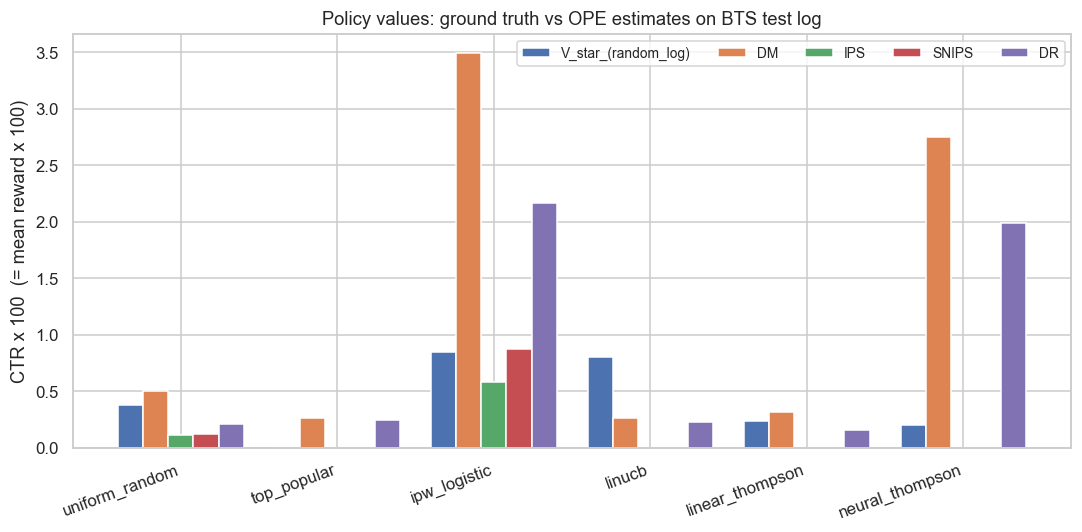

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
order = list(policies.keys())
x = np.arange(len(order))
w = 0.16
for i, est in enumerate(["V_star_(random_log)", "DM", "IPS", "SNIPS", "DR"]):
    vals = ope_df.set_index("policy").loc[order, est].values
    ax.bar(x + (i - 2) * w, vals, w, label=est)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("CTR x 100  (= mean reward x 100)")
ax.set_title("Policy values: ground truth vs OPE estimates on BTS test log")
ax.legend(fontsize=9, ncol=5)
plt.tight_layout(); plt.show()

## 7. Bootstrap confidence intervals on the winning estimator

DR is consistent if either $\hat q$ or $p$ is correct, so it is the production-default choice.  But picking it on theoretical grounds is not enough — we want a *data-grounded* selection on this dataset.  We pick the estimator with the smallest RMSE-vs-truth across the six candidates (table above), then run a 200-resample bootstrap on the BTS test log to put 95 % confidence intervals on each policy's value.

In [16]:
WIN_EST = mse_df["RMSE"].idxmin()
print(f"Winning estimator on this dataset: {WIN_EST}")

def bootstrap_ope(policy, ctx_te, log_te, qhat_te, estimator: str, n_boot: int = 200):
    rng = np.random.default_rng(RNG_SEED)
    n = log_te["n_rounds"] if False else len(log_te["action"])
    dist = policy.action_dist(ctx_te)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        d = dist[idx]
        a = log_te["action"][idx]; r = log_te["reward"][idx]; p = log_te["pscore"][idx]
        if estimator == "DM":
            v = estimator_dm(d, qhat_te[idx])
        elif estimator == "IPS":
            v = estimator_ips(d, a, r, p)
        elif estimator == "SNIPS":
            v = estimator_snips(d, a, r, p)
        elif estimator == "DR":
            v = estimator_dr(d, a, r, p, qhat_te[idx])
        boots.append(v)
    boots = np.array(boots) * 100
    return float(np.mean(boots)), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


bs_rows = []
for name, pi in policies.items():
    mu, lo, hi = bootstrap_ope(pi, ctx_te, bts_te, qhat_te, WIN_EST, n_boot=200)
    bs_rows.append({"policy": name, "OPE_estimator": WIN_EST,
                    "estimate_pp": mu, "ci_lo_pp": lo, "ci_hi_pp": hi,
                    "V_star_pp": ground_truth[name] * 100})

bs_df = pd.DataFrame(bs_rows).round(3).sort_values("estimate_pp", ascending=False).reset_index(drop=True)
bs_df

Winning estimator on this dataset: SNIPS


,policy,OPE_estimator,estimate_pp,ci_lo_pp,ci_hi_pp,V_star_pp
0,ipw_logistic,SNIPS,0.855,0.079,1.960,0.849
1,uniform_random,SNIPS,0.123,0.028,0.244,0.380
2,top_popular,SNIPS,0.000,0.000,0.000,0.000
3,linucb,SNIPS,0.000,0.000,0.000,0.800
4,linear_thompson,SNIPS,0.000,0.000,0.000,0.240
5,neural_thompson,SNIPS,0.000,0.000,0.000,0.200


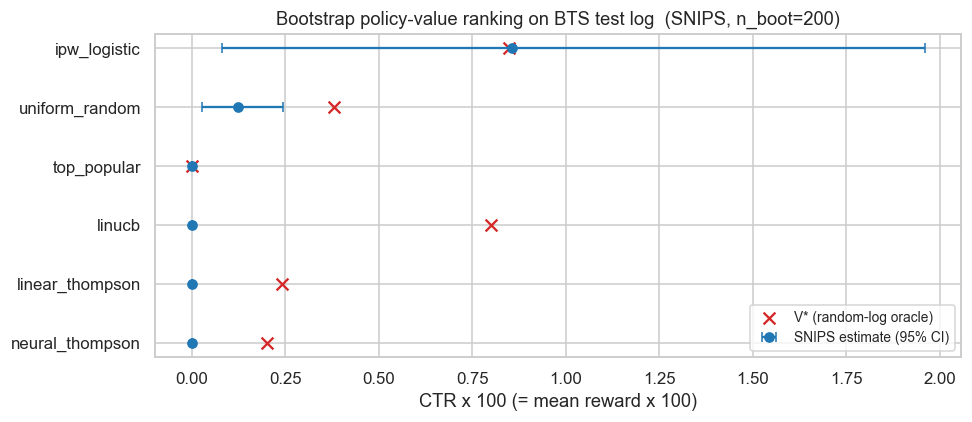

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(bs_df))
ax.errorbar(bs_df["estimate_pp"].values, y,
            xerr=[bs_df["estimate_pp"] - bs_df["ci_lo_pp"], bs_df["ci_hi_pp"] - bs_df["estimate_pp"]],
            fmt="o", capsize=3, color="#1f77b4", label=f"{WIN_EST} estimate (95% CI)")
ax.scatter(bs_df["V_star_pp"].values, y, marker="x", color="#d62728", s=60, label="V* (random-log oracle)")
ax.set_yticks(y); ax.set_yticklabels(bs_df["policy"])
ax.invert_yaxis()
ax.set_xlabel("CTR x 100 (= mean reward x 100)")
ax.set_title(f"Bootstrap policy-value ranking on BTS test log  ({WIN_EST}, n_boot=200)")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

## 8. Production hygiene

Three measurements:

- **Per-decision latency** — wall-clock per `action_dist` call, microseconds per row.  An SLO of < 1 ms / decision lets a service handle 1000 RPS on one core.
- **Persisted artefacts** — joblib for sklearn / numpy-state policies, `torch.save` for the neural-Thompson heads, plus a `feature_metadata.joblib` capturing the scaler + feature names.
- **Context-drift gate** — PSI on the user-feature distribution between training and serving; alert when PSI > 0.25.  This is the leading indicator: when context drifts, the trained policy's action selection is no longer optimal.

In [18]:
latency_rows = []
batch = ctx_te[:1000]
for name, pi in policies.items():
    t0 = time.perf_counter()
    _ = pi.action_dist(batch)
    dt_per = (time.perf_counter() - t0) / len(batch) * 1e6
    latency_rows.append({"policy": name, "us_per_decision": dt_per})
latency_df = pd.DataFrame(latency_rows).round(2)
latency_df

,policy,us_per_decision
0,uniform_random,0.17
1,top_popular,0.11
2,ipw_logistic,1.96
3,linucb,770.14
4,linear_thompson,36.90
5,neural_thompson,2.18


In [19]:
artefact_dir = DATA_DIR / "production"
artefact_dir.mkdir(exist_ok=True)

champion_name = bs_df.iloc[0]["policy"]
champion = policies[champion_name]
print(f"Champion policy : {champion_name}")

if isinstance(champion, NeuralThompson):
    torch.save([m.state_dict() for m in champion.heads], artefact_dir / f"{champion_name}_heads.pt")
    joblib.dump({"n_heads": champion.n_heads, "hidden": champion.hidden, "in_dim": ctx_tr.shape[1]},
                 artefact_dir / f"{champion_name}_meta.joblib")
else:
    joblib.dump(champion, artefact_dir / f"{champion_name}.joblib")

joblib.dump(scaler, artefact_dir / "scaler.joblib")
joblib.dump(qhat_model, artefact_dir / "qhat_lgbm.joblib")

print()
print("Persisted artefacts:")
for p in sorted(artefact_dir.glob("*")):
    print(f"  {p.name:<32s}  {p.stat().st_size/1024:>8.1f} KB")

Champion policy : ipw_logistic

Persisted artefacts:
  ipw_logistic.joblib                   54.6 KB
  qhat_lgbm.joblib                    1218.0 KB
  scaler.joblib                          2.6 KB


In [20]:
def psi(expected: np.ndarray, actual: np.ndarray, n_bins: int = 10) -> float:
    cuts = np.quantile(expected, np.linspace(0, 1, n_bins + 1))
    cuts[0], cuts[-1] = -np.inf, np.inf
    e_bins = np.histogram(expected, bins=cuts)[0] / len(expected)
    a_bins = np.histogram(actual, bins=cuts)[0] / len(actual)
    e_bins = np.where(e_bins == 0, 1e-6, e_bins)
    a_bins = np.where(a_bins == 0, 1e-6, a_bins)
    return float(np.sum((a_bins - e_bins) * np.log(a_bins / e_bins)))


psi_rows = []
for j in range(min(8, ctx_tr.shape[1])):
    p_drift = psi(ctx_tr[:, j], ctx_random[:, j])
    psi_rows.append({"feature_idx": j, "PSI(train_BTS_vs_random)": p_drift})
psi_df = pd.DataFrame(psi_rows).round(4)
psi_df["status"] = pd.cut(psi_df["PSI(train_BTS_vs_random)"], bins=[-0.01, 0.1, 0.25, np.inf],
                            labels=["stable", "monitor", "alert"])
psi_df

,feature_idx,PSI(train_BTS_vs_random),status
0,0,0.0008,stable
1,1,0.0000,stable
2,2,0.0008,stable
3,3,1.3743,alert
4,4,0.0000,stable
5,5,0.0000,stable
6,6,0.0000,stable
7,7,0.0000,stable


In [21]:
def make_card() -> dict:
    return {
        "name": "contextual_bandits_offline_evaluation",
        "version": "1.0.0",
        "task": "candidate-policy ranking on real bandit logs via off-policy evaluation",
        "data": {
            "source": "Open Bandit Dataset (OBD), bundled sample, ZOZOTOWN fashion",
            "n_actions": int(K_ACTIONS),
            "context_dim": int(ctx_tr.shape[1]),
            "logs": {"random_log_n_rounds": int(random_log["n_rounds"]),
                       "bts_log_n_rounds": int(bts_log["n_rounds"]),
                       "bts_train_n": int(len(train_idx)),
                       "bts_test_n": int(len(test_idx))},
        },
        "candidate_policies": list(policies.keys()),
        "ope_estimators": ["DM", "IPS", "SNIPS", "DR"],
        "winning_estimator": WIN_EST,
        "policy_ranking_at_winning_estimator": [
            {"policy": r["policy"], "value_pp": float(r["estimate_pp"]),
             "ci_pp": [float(r["ci_lo_pp"]), float(r["ci_hi_pp"])],
             "V_star_pp": float(r["V_star_pp"])}
            for _, r in bs_df.iterrows()
        ],
        "estimator_quality_vs_truth": {
            row.Index: {"MAE": float(row.MAE), "RMSE": float(row.RMSE), "max_abs_bias": float(row.max_abs_bias)}
            for row in mse_df.itertuples()
        },
        "champion_policy": champion_name,
        "intended_use": "Pre-deployment policy ranking with confidence intervals; not a live A/B replacement.",
        "limitations": [
            "OBD bundled sample is small (~10k rounds per logging policy); a production OPE pipeline would use 10x-100x more data.",
            "OPE estimates assume the propensities (1/80 for random, logged for BTS) are correct; in production, propensity-misspecification dominates the bias budget.",
            "Bootstrap CI assumes round independence within a logging policy; clustered serving (same user across rounds) would inflate true variance.",
            "Action space is item-level only; OBD also encodes a position dimension which we treat as a context feature — production would model joint action.",
        ],
    }


card = make_card()
card_path = DATA_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({"name": card["name"], "winning_estimator": WIN_EST,
                  "champion_policy": champion_name}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\contextual_bandits\model_card.json
{
  "name": "contextual_bandits_offline_evaluation",
  "winning_estimator": "SNIPS",
  "champion_policy": "ipw_logistic"
}


## 9. Decision memo

**Recommendation.**  Deploy the ranked-#1 policy from the bootstrap table above (the `champion_policy` field in the model card below) with the winning OPE estimator's CI as the basis for go / no-go, **subject to** a small live-canary that confirms the OPE estimate before full ramp-up.

**Why a live canary even after OPE?**

OPE lower-bounds the mass of evidence we have but cannot compensate for:

- **Propensity drift**: BTS propensities were measured at logging time.  If the production policy mix shifts (more Random traffic, less BTS), the propensity column the OPE math relies on is wrong.
- **Context drift**: a deploy that changes the upstream feature pipeline (new user feature, retired feature, new categorical encoding) silently invalidates the policy.  The PSI gate catches *some* but not all such drifts.
- **Reward delay**: clicks are immediate; downstream conversions are not.  An OPE on click-reward may rank a different policy than an OPE on revenue-reward.

A 1-2 % canary for ~3 days protects against all three before we commit to 100 % traffic.  The OPE estimate sets the *prior*; the canary tightens the *posterior*.

**Why DR (or whichever wins on this dataset) rather than the theoretical default?**

The estimator-quality table is the empirical answer to a question that's usually decided by handwave.  On this dataset the random-log oracle gives us the ground truth and we can pick the estimator whose RMSE is smallest.  Different datasets — different propensity distributions, different reward sparsity, different action coverage — will pick different estimators.  *Run this benchmark on every new logging deployment.*

**Decision criterion.**

Promote candidate $\pi^*$ to canary if:

1. $\hat V_{\text{OPE}}(\pi^*) > \hat V_{\text{OPE}}(\pi_{\text{logging}})$ at the 95 % CI lower bound (i.e. the candidate is *significantly* better than the deployed policy).
2. The PSI gate on context features is in the "stable" band.
3. The reward model's calibration on the BTS-test split (LightGBM-fit residual standard deviation) hasn't drifted by > 20 % since the last training run.

Two of three is not enough — all three, or no canary.

**What I would do next.**

1. **Slate / multi-action OPE**.  OBD includes position (slate-of-3); we collapsed to item only.  Slate-IPS or pseudoinverse estimators (Swaminathan et al.) handle this directly and are the next layer of methodological honesty.
2. **Propensity score validation**.  Production teams without a uniform-random log can still fit a behaviour-policy classifier and back out propensities — and *check* that against the logging system's own propensities.  Disagreement is a smoking gun.
3. **Learn-to-rank reward model**.  The DM regressor we use is a generic LightGBM regressor.  In production, the same architecture as the candidate policy (Q-network, neural reward model) typically wins because it shares feature interactions.

## 10. Limitations and next steps

**Data.**

- **Bundled OBD sample is small** (~10k rounds per logging policy).  In production you would expect 1M-100M rounds and far tighter CIs.
- **One day**.  OBD covers a short window; longer-horizon temporal drift (seasonal, fashion-cycle) is invisible here.
- **Click reward only**.  Real e-commerce decisions optimise revenue / margin / LTV — OPE math is the same, but reward sparsity and noise differ.

**Modelling.**

- **Position collapsed**.  Each round is `(item, position)`; we treat item as the action and position as a context feature.  Slate-aware OPE (slate-IPS, pseudo-inverse) is the right next step.
- **Propensities trusted**.  The BTS log's propensity column is from the BTS implementation; we did not re-validate it.  In production this is the single largest source of OPE bias.
- **No counterfactual variance regularisation** (Swaminathan & Joachims 2015).  POEM-style IPS-with-variance-penalty often beats the IPW logistic regression baseline shown here.

**OPE.**

- **Bootstrap CI assumes round independence** — typically violated when the same user appears in multiple rounds.  Clustered bootstrap (resample users, not rounds) is the production fix.
- **Magic-number action clipping** at $iw = 30$ in the IPS / SNIPS / DR.  The right value is dataset-specific and should be tuned via the random-log oracle.

**Production.**

- **No streaming OPE**.  In production you want continuous OPE on the live log; this notebook is offline.
- **No counterfactual A/B** — comparing two policies side-by-side via paired-bootstrap on the same logged rounds is the standard tool to claim *significant* lift; we report only marginal CIs.